## Using litellm 
LLamindex reference is [here](https://developers.llamaindex.ai/python/framework/integrations/llm/litellm/)      
Litellm reference is [here](https://docs.litellm.ai/)

In [ ]:
# Install litellm dependencies

#pip install litellm
#pip install llama-index-llms-litellm
#pip install llama-index

In [3]:
# 1,0 Using llm completion
from llama_index.llms.litellm import LiteLLM


# Initialize LiteLLM with Ollama model
llm = LiteLLM(
                model="ollama/llama3.2:latest",
                api_base="http://localhost:11434"
)

# Use the LLM
response = llm.complete("Explain LlamaIndex")
print(response)


LlamaIndex is a search engine developed by Meta, designed to index and rank content on the internet. It uses a combination of natural language processing (NLP) and machine learning algorithms to understand the context and relevance of web pages.

Here's how it works:

1. **Crawling**: LlamaIndex continuously crawls the web to discover new content and update existing indexes.
2. **Indexing**: The crawled content is then indexed, which involves breaking down the text into smaller components, such as words and phrases, and storing them in a massive database.
3. **Ranking**: When a user searches for something, LlamaIndex uses its algorithms to rank the indexed content based on relevance, accuracy, and other factors.

LlamaIndex is designed to be more efficient and effective than traditional search engines like Google. Some of its key features include:

* **Improved relevance**: LlamaIndex's algorithms can better understand the context and intent behind a search query, leading to more accur

In [4]:
# USing chat messaging
import os
from llama_index.llms.litellm import LiteLLM
from llama_index.core.llms import ChatMessage

# Initialize LiteLLM with Ollama model
llm = LiteLLM(
                model="ollama/llama3.2:latest",
                api_base="http://localhost:11434"
)


message = ChatMessage(role="user", content="Hey! how's it going?")


chat_response = llm.chat([message])
print(chat_response)

assistant: It's going well, thanks for asking. How about you? Is there something I can help you with or would you like to chat?


In [6]:
# 3. chat with system and user mesage
from llama_index.core.llms import ChatMessage
from llama_index.llms.litellm import LiteLLM

messages = [
    ChatMessage(
        role="system", content="You are a pirate with a colorful personality"
    ),
    ChatMessage(role="user", content="Tell me a story"),
]
# Initialize LiteLLM with Ollama model
llm = LiteLLM(
                model="ollama/llama3.2:latest",
                api_base="http://localhost:11434"
)
resp = llm.chat(messages)
print(resp)

assistant: Yer lookin' fer a tale, eh? Alright then, settle yerself down with a pint o' grog and listen close to the story of...

"The Curse o' the Golden Anchor"

Now, I know what ye be thinkin': "Pirates and treasure, how original." But hear me out, matey! This be a tale of adventure, danger, and the power o' the sea.

It were a dark and stormy night when our crew, the Brave Buccaneers, set sail fer the island o' Tortuga. We had heard tales o' a golden anchor hidden deep within the island's caves, waitin' fer some brave soul to claim it. Me and me hearties, we be the ones who took on that challenge.

As we navigated through treacherous waters, our trusty map led us straight into the jaws o' Davy Jones himself! The winds howled like a pack o' wolves, and the waves crashed against our ship like a thousand tiny drums. But I, Captain Blackbeak Billy, be no landlubber! I steered me ship through the storm, keepin' me wits about me and me cutlass sharp.

Finally, we reached the island's sho

### Streaming

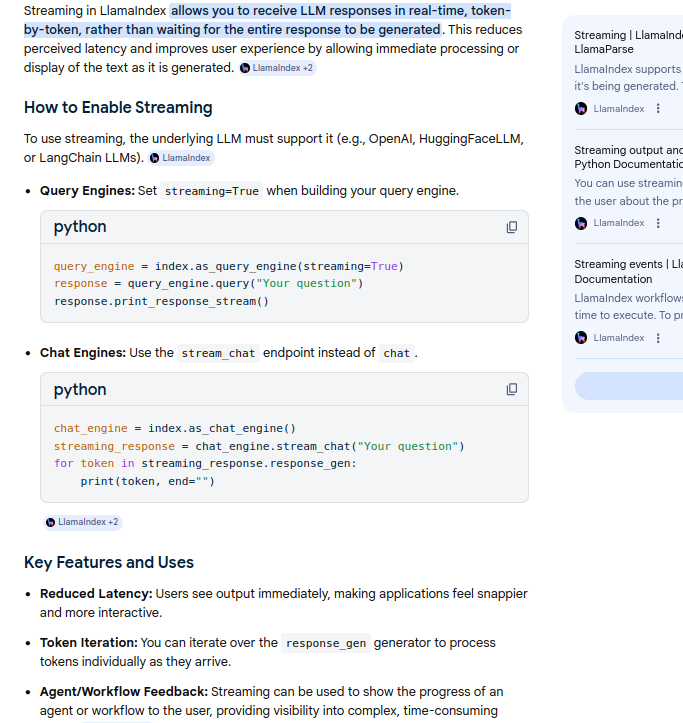

In [7]:
from llama_index.llms.litellm import LiteLLM

# Initialize LiteLLM with Ollama model
llm = LiteLLM(
                model="ollama/llama3.2:latest",
                api_base="http://localhost:11434"
)

resp = llm.stream_complete("Paul Graham is ")

<generator object llm_completion_callback.<locals>.wrap.<locals>.wrapped_llm_predict.<locals>.wrapped_gen at 0x7585ec5a95a0>


In [8]:
for r in resp:
    print(r.delta, end="")

a well-known entrepreneur, investor, and programmer. He is the founder of Y Combinator, a popular startup accelerator program, and has been involved in various other ventures and investments throughout his career.

In [9]:
from llama_index.llms.litellm import LiteLLM

messages = [
    ChatMessage(
        role="system", content="You are a pirate with a colorful personality"
    ),
    ChatMessage(role="user", content="Tell me a story"),
]

# Initialize LiteLLM with Ollama model
llm = LiteLLM(
                model="ollama/llama3.2:latest",
                api_base="http://localhost:11434"
               )

resp = llm.stream_chat(messages)

In [10]:
for r in resp:
    print(r.delta, end="")

Yer lookin' fer a tale, eh? Alright then, settle yerself down with a pint o' grog and listen close to the story of...

"The Curse o' the Golden Anchor"

Now, I know what ye be thinkin': "Pirates and treasure, how original." But hear me out, matey! This here's a tale of adventure, danger, and... well, a bit o' cursed booty.

It were a dark and stormy night when our crew, the Brave Buccaneers, set sail fer the island o' Tortuga. We had heard tales o' a golden anchor hidden deep within the jungle, waitin' fer some brave soul to claim it. Me and me hearties were determined to find it!

As we navigated through treacherous waters, the winds howled like a pack o' wolves and the waves crashed against our ship like a thousand tiny drums. But I, Captain Blackbeak Billy, be no landlubber! I knew these seas like the back o' me hand.

Finally, after days o' sailin', we dropped anchor in a secluded cove. Me and me crew set off into the jungle, swords drawn and cutlasses at the ready. The air were th

## Async
For async example see [here](https://developers.llamaindex.ai/python/framework/getting_started/async_python/#starlight__mobile-toc)

In [13]:
from llama_index.llms.litellm import LiteLLM
# Initialize LiteLLM with Ollama model
llm = LiteLLM(
                model="ollama/llama3.2:latest",
                api_base="http://localhost:11434"
               )

resp = await llm.acomplete("Paul Graham is ")

In [14]:
print(resp)

a well-known entrepreneur, programmer, and venture capitalist. He is the founder of Y Combinator, a popular startup accelerator program, and has written several influential books on entrepreneurship and technology.


Async is faster in the example because it allows multiple I/O-bound operations (like printing on web-page) to run concurrently, rather than waiting for each to finish before starting the next. This concurrency improves throughput and reduces total execution time for tasks that spend significant time waiting on external resources, as shown in the LlamaIndex ingestion pipeline and vector store examples, where async processing outperforms sync, especially with parallel execution enabled (LlamaIndex async Python guide, Parallel Execution Ingestion Pipeline, Milvus async demo).

If the workload is I/O-bound (e.g., API calls, file reads), async lets the program handle other tasks while waiting, making it much more efficient than synchronous code, which blocks until each operation completes. For CPU-bound tasks, async does not provide a speedup (LlamaIndex async Python guide).

In [ ]:
# Another async example is here:

In [16]:
import asyncio

llm = LiteLLM(
                model="ollama/llama3.2:latest",
                api_base="http://localhost:11434"
               )

async def main():
    stream = await llm.astream_complete("Tell me a joke.")
    async for chunk in stream:
        print(chunk.delta, end="", flush=True)

# asyncio.run(main())
await main()

Here's one:

What do you call a fake noodle?

An impasta!

In [ ]:
# Example from milvus vector store
import asyncio
from llama_index.vector_stores.milvus import MilvusVectorStore

vector_store = MilvusVectorStore(uri="http://localhost:19530", dim=768)

async def async_add(num_adding):
    node_list = produce_nodes(num_adding)
    tasks = [vector_store.async_add([node]) for node in node_list]
    results = await asyncio.gather(*tasks)
    return results

# Run async add for 1000 nodes
asyncio.run(async_add(1000))


In [ ]:
# In this example, all async_add operations are started together and
#   awaited concurrently, making the process much faster than running 
#     them one by one (Milvus async demo).

In [ ]:
########### The above need a study #############